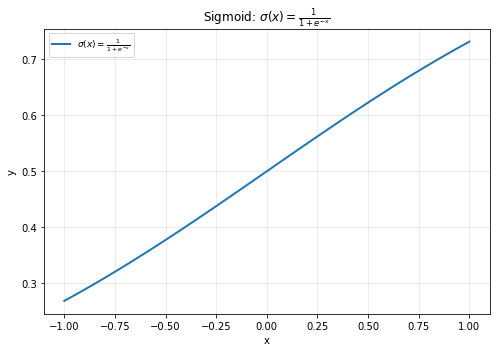

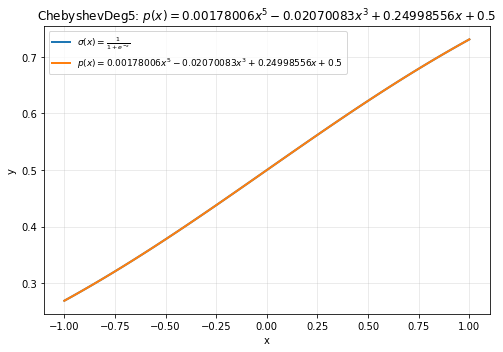

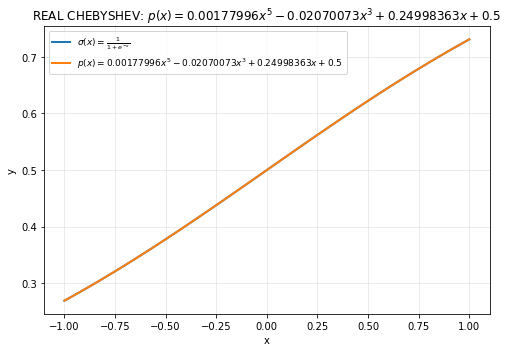

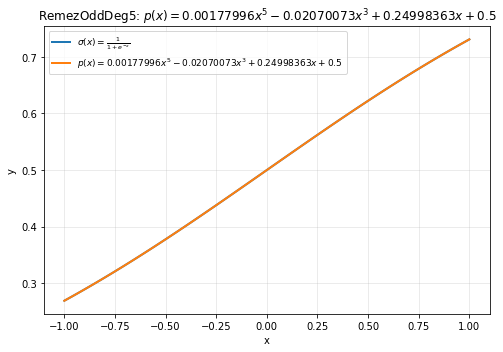

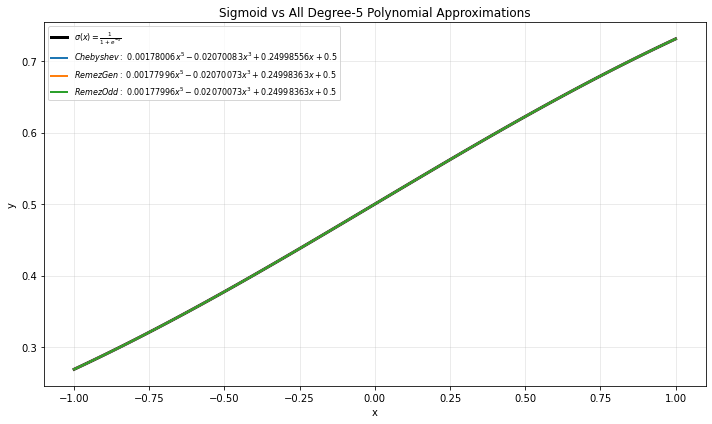

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

CHEBYSHEV_DEG5_CURRENT_COEFFS = [
    0.5,
    0.24998556,
    0.0,
    -0.02070083,
    0.0,
    0.00178006,
]

REMEZ_GENERAL_DEG5_COEFFS = [
    0.5,
    0.249983628,
    0.0,
    -0.0207007336,
    0.0,
    0.00177995692,
]

REMEZ_ODD_DEG5_COEFFS = [
    0.5,
    0.24998363,
    0.0,
    -0.02070073,
    0.0,
    0.00177996,
]


def sigmoid(x):
    x = np.asarray(x, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-x))


def poly_eval(x, coeffs):
    x = np.asarray(x, dtype=np.float64)
    y = np.zeros_like(x)
    for i, c in enumerate(coeffs):
        y += c * (x ** i)
    return y


def chebyshev_deg5(x):
    return poly_eval(x, CHEBYSHEV_DEG5_CURRENT_COEFFS)


def remez_general_deg5(x):
    return poly_eval(x, REMEZ_GENERAL_DEG5_COEFFS)


def remez_odd_deg5(x):
    return poly_eval(x, REMEZ_ODD_DEG5_COEFFS)


def coeffs_to_formula(coeffs, var='x', precision=8):
    terms = []

    for power in range(len(coeffs) - 1, -1, -1):
        c = coeffs[power]
        if np.isclose(c, 0.0):
            continue

        c_abs = abs(c)
        c_str = f"{c_abs:.{precision}f}".rstrip('0').rstrip('.')

        if power == 0:
            term = f"{c_str}"
        elif power == 1:
            term = f"{c_str}{var}"
        else:
            term = f"{c_str}{var}^{power}"

        if not terms:
            terms.append(f"-{term}" if c < 0 else term)
        else:
            terms.append(f" - {term}" if c < 0 else f" + {term}")

    return "".join(terms)


x = np.linspace(-1, 1, 100)

y_sigmoid = sigmoid(x)
y_cheb = chebyshev_deg5(x)
y_rg = remez_general_deg5(x)
y_ro = remez_odd_deg5(x)

cheb_formula = coeffs_to_formula(CHEBYSHEV_DEG5_CURRENT_COEFFS)
rg_formula = coeffs_to_formula(REMEZ_GENERAL_DEG5_COEFFS)
ro_formula = coeffs_to_formula(REMEZ_ODD_DEG5_COEFFS)

sigmoid_formula = r'\sigma(x)=\frac{1}{1+e^{-x}}'


# 0) sigmoid alone
plt.figure(figsize=(7, 5))
plt.plot(x, y_sigmoid, label=rf'${sigmoid_formula}$', linewidth=2)
plt.title(rf'Sigmoid: ${sigmoid_formula}$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


# 1) sigmoid vs ChebyshevDeg5
plt.figure(figsize=(7, 5))
plt.plot(x, y_sigmoid, label=rf'${sigmoid_formula}$', linewidth=2)
plt.plot(x, y_cheb, label=rf'$p(x)={cheb_formula}$', linewidth=2)
plt.title(rf'ChebyshevDeg5: $p(x)={cheb_formula}$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


# 2) sigmoid vs RemezGeneralDeg5
plt.figure(figsize=(7, 5))
plt.plot(x, y_sigmoid, label=rf'${sigmoid_formula}$', linewidth=2)
plt.plot(x, y_rg, label=rf'$p(x)={rg_formula}$', linewidth=2)
plt.title(rf'RemezGeneralDeg5: $p(x)={rg_formula}$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


# 3) sigmoid vs RemezOddDeg5
plt.figure(figsize=(7, 5))
plt.plot(x, y_sigmoid, label=rf'${sigmoid_formula}$', linewidth=2)
plt.plot(x, y_ro, label=rf'$p(x)={ro_formula}$', linewidth=2)
plt.title(rf'RemezOddDeg5: $p(x)={ro_formula}$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


# 4) all in one
plt.figure(figsize=(10, 6))
plt.plot(x, y_sigmoid, label=rf'${sigmoid_formula}$', linewidth=3, color='black')
plt.plot(x, y_cheb, label=rf'$Chebyshev:\ {cheb_formula}$', linewidth=2)
plt.plot(x, y_rg, label=rf'$RemezGen:\ {rg_formula}$', linewidth=2)
plt.plot(x, y_ro, label=rf'$RemezOdd:\ {ro_formula}$', linewidth=2)
plt.title('Sigmoid vs All Degree-5 Polynomial Approximations')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import time
import numpy as np

# =========================================================
# 1) target
# =========================================================
def sigmoid(x):
    x = np.asarray(x, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-x))

# =========================================================
# 2) given deg5 coeffs
#    coeffs = [c0, c1, c2, c3, c4, c5, ...]
# =========================================================
CHEBYSHEV_DEG5_CURRENT_COEFFS = [
    0.5,
    0.24998556,
    0.0,
    -0.02070083,
    0.0,
    0.00178006,
]

REMEZ_ODD_DEG5_COEFFS = [
    0.5,
    0.24998363,
    0.0,
    -0.02070073,
    0.0,
    0.00177996,
]

# =========================================================
# 3) odd polynomial evaluation
#    p(x) = 0.5 + a1*x + a3*x^3 + a5*x^5 + a7*x^7
# =========================================================
def eval_poly(x, coeffs):
    x = np.asarray(x, dtype=np.float64)
    y = np.zeros_like(x)
    for d, c in enumerate(coeffs):
        y += c * (x ** d)
    return y

def eval_odd_poly(x, odd_coeffs):
    # odd_coeffs = [c0, c1, c3, c5, c7]
    x = np.asarray(x, dtype=np.float64)
    c0, c1, c3, c5, c7 = odd_coeffs
    return c0 + c1*x + c3*(x**3) + c5*(x**5) + c7*(x**7)

# =========================================================
# 4) utility
# =========================================================
def to_odd_deg7_coeffs(full_coeffs, tol=1e-12):
    """
    full coeffs -> [c0, c1, c3, c5, c7]
    even coeffs are discarded.
    """
    c = list(full_coeffs) + [0.0] * (8 - len(full_coeffs))
    vals = [c[0], c[1], c[3], c[5], c[7]]
    vals = [0.0 if abs(v) < tol else v for v in vals]
    return vals

def odd_list_to_full_coeffs(odd_coeffs):
    c0, c1, c3, c5, c7 = odd_coeffs
    return [c0, c1, 0.0, c3, 0.0, c5, 0.0, c7]

# =========================================================
# 5) odd Chebyshev deg7 generation
#    방법:
#    - centered target: g(x)=sigmoid(x)-0.5
#    - odd-only projection using symmetric averaging
#    - final form: 0.5 + a1 x + a3 x^3 + a5 x^5 + a7 x^7
# =========================================================
def make_chebyshev_odd_deg7_coeffs_on_interval(a, b, n_samples=20001):
    # 대칭 구간 전제
    x = np.linspace(a, b, n_samples)
    y = sigmoid(x) - 0.5

    # 일반 7차 polyfit
    full = np.polyfit(x, y, deg=7)  # descending order

    # descending -> ascending
    full_asc = full[::-1]  # [c0, c1, ..., c7]

    # odd-only projection
    odd = [0.0, 0.0, 0.0, 0.0, 0.0]
    odd[0] = 0.5
    odd[1] = full_asc[1]
    odd[2] = full_asc[3]
    odd[3] = full_asc[5]
    odd[4] = full_asc[7]

    return odd

# =========================================================
# 6) odd Remez-like deg7 generation
#    - minimax objective on dense grid
#    - odd-only form enforced
# =========================================================
def make_remez_odd_deg7_coeffs_on_interval(a, b, n_grid=20001, n_iter=250):
    x = np.linspace(a, b, n_grid)
    y = sigmoid(x)

    # initial guess from least squares with odd basis
    A = np.column_stack([np.ones_like(x), x, x**3, x**5, x**7])
    target = y
    beta, *_ = np.linalg.lstsq(A, target, rcond=None)

    # force c0 = 0.5
    beta[0] = 0.5

    best = beta.copy()
    best_err = np.max(np.abs(eval_odd_poly(x, best) - y))

    rng = np.random.default_rng(0)

    # 간단한 coordinate/random search
    step = np.array([0.0, 1e-3, 1e-3, 1e-4, 1e-5], dtype=np.float64)

    for _ in range(n_iter):
        improved = False

        for j in [1, 2, 3, 4]:
            for direction in (-1.0, 1.0):
                cand = best.copy()
                cand[j] += direction * step[j]
                cand[0] = 0.5
                err = np.max(np.abs(eval_odd_poly(x, cand) - y))
                if err < best_err:
                    best = cand
                    best_err = err
                    improved = True

        for _k in range(8):
            cand = best.copy()
            cand[1:] += rng.normal(0.0, step[1:], size=4)
            cand[0] = 0.5
            err = np.max(np.abs(eval_odd_poly(x, cand) - y))
            if err < best_err:
                best = cand
                best_err = err
                improved = True

        if not improved:
            step[1:] *= 0.5
            if np.max(step[1:]) < 1e-14:
                break

    return best.tolist()

# =========================================================
# 7) build odd deg5 / odd deg7 models
# =========================================================
CHEB_ODD_DEG5 = [0.5, 0.24998556, -0.02070083, 0.00178006, 0.0]
REMEZ_ODD_DEG5 = [0.5, 0.24998363, -0.02070073, 0.00177996, 0.0]

def deg5odd_to_deg7odd(odd5):
    # [c0, c1, c3, c5, 0]
    return [odd5[0], odd5[1], odd5[2], odd5[3], 0.0]

# =========================================================
# 8) pretty print like attached image
# =========================================================
def print_comparison_block(name, x_vals, y_true, y_pred, mean_eval_time):
    abs_err = np.abs(y_pred - y_true)

    print(f"===== {name} =====")
    print("idx |        x | true sigmoid |   APPROX   |      abs err")
    print("-" * 66)

    for idx, (x, yt, yp, err) in enumerate(zip(x_vals, y_true, y_pred, abs_err)):
        print(
            f"{idx:>3} | "
            f"{x:>8.6f} | "
            f"{yt:>12.8f} | "
            f"{yp:>11.8f} | "
            f"{err:>12.8f}"
        )

    print()
    print(f"{name} vs true sigmoid")
    print(f"{name} np.allclose(atol=1e-2, rtol=1e-3): {np.allclose(y_true, y_pred, atol=1e-2, rtol=1e-3)}")
    print(f"{name} max abs err: {np.max(abs_err)}")
    print(f"{name} mean abs err: {np.mean(abs_err)}")
    print(f"{name} mean eval time (sec): {mean_eval_time:.6f}")
    print()

def benchmark_eval(func, x_vals, repeat=5):
    times = []
    out = None
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = func(x_vals)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return out, float(np.mean(times))

# =========================================================
# 9) main comparison
# =========================================================
intervals = [
    (-1.0, 1.0),
    (-1.2, 1.2),
    (-1.5, 1.5),
]

for a, b in intervals:
    print()
    print("=" * 18 + f" APPROX vs TRUE SIGMOID ON [{a}, {b}] " + "=" * 18)
    print("repeat for mean eval time: 5")
    print()

    x_test = np.linspace(a, b, 10)
    y_true = sigmoid(x_test)

    cheb7_odd = make_chebyshev_odd_deg7_coeffs_on_interval(a, b)
    remez7_odd = make_remez_odd_deg7_coeffs_on_interval(a, b)

    # 계수 출력
    print("Generated odd coeffs on this interval")
    print("ChebyshevOddDeg7 =", cheb7_odd)
    print("RemezOddDeg7     =", remez7_odd)
    print()

    models = {
        "UnitRemezOddDeg5Sigmoid_HE": deg5odd_to_deg7odd(REMEZ_ODD_DEG5),
        "UnitChebyshevOddDeg5Sigmoid_HE": deg5odd_to_deg7odd(CHEB_ODD_DEG5),
        "UnitRemezOddDeg7Sigmoid_HE": remez7_odd,
        "UnitChebyshevOddDeg7Sigmoid_HE": cheb7_odd,
    }

    for model_name, coeffs in models.items():
        pred, mean_t = benchmark_eval(lambda xx: eval_odd_poly(xx, coeffs), x_test, repeat=5)
        print_comparison_block(model_name, x_test, y_true, pred, mean_t)


================== APPROX vs TRUE SIGMOID ON [-1.0, 1.0] ==================
repeat for mean eval time: 5

Generated odd coeffs on this interval
ChebyshevOddDeg7 = [0.5, 0.24999955826294137, -0.020826761630274696, 0.002057083241803473, -0.00017147061089025858]
RemezOddDeg7     = [0.5, 0.24999955826294132, -0.020826761630272153, 0.0020570832418005947, -0.00017140706728560788]

===== UnitRemezOddDeg5Sigmoid_HE =====
idx |        x | true sigmoid |   APPROX   |      abs err
------------------------------------------------------------------
  0 | -1.000000 |   0.26894142 |  0.26893714 |   0.00000428
  1 | -0.777778 |   0.31479902 |  0.31480151 |   0.00000249
  2 | -0.555556 |   0.36457644 |  0.36457551 |   0.00000093
  3 | -0.333333 |   0.41742979 |  0.41743149 |   0.00000170
  4 | -0.111111 |   0.47225076 |  0.47225241 |   0.00000164
  5 | 0.111111 |   0.52774924 |  0.52774759 |   0.00000164
  6 | 0.333333 |   0.58257021 |  0.58256851 |   0.00000170
  7 | 0.555556 |   0.63542356 |  0.6354

In [1]:
import numpy as np
from numpy.polynomial import chebyshev

# 1. Sigmoid 함수 정의
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2. [-1, 1] 구간에서 촘촘한 균등 간격의 데이터 생성
x = np.linspace(-1, 1, 10000)
y = sigmoid(x)

# 3. 체비쇼프 다항식 피팅을 통해 5차 근사 수행
cheb_coef = chebyshev.chebfit(x, y, 5)

# 4. 체비쇼프 기저를 표준 다항식(x^n) 기저로 변환하여 출력
poly_coef = chebyshev.cheb2poly(cheb_coef)
print(poly_coef)

[ 5.00000000e-01  2.49985561e-01 -1.00879950e-15 -2.07008070e-02
  1.16480979e-15  1.78003762e-03]
